# FINE speed + GPU `A_h` — compare runs

This notebook is meant to be **opened before the continuation jobs finish**.

1. Run the **`A_h` microbench** cell now (no MAGNET, no forecast). That is the clean GPU vs CPU kernel check.
2. Launch continuation timing from a terminal (commands below). Results land in `outputs/fine_speed_benchmark/<RUN_ID>/`.
3. Re-run the **load timings** cells after jobs complete.

Worktree: `etas-fine-speed-gpu` on `feature/fine-speed-gpu-ah`. Do not `git checkout` in `~/Repos/etas`.

**What is timed**

| Arm | Measures | Needs MAGNET incremental files? |
|-----|----------|----------------------------------|
| `thinning_cpu` / `thinning_gpu` | Ogata thinning + `A_h` (GR magnitudes) | No |
| `FINE_cpu` / `FINE_gpu` | Same + MAGNET magnitudes | Yes |

Timed arms use `--force-rerun` after a shared inversion (and optional MAGNET train) so wall-clock is **forecast only**, not invert/train.

Do **not** set `CUDA_VISIBLE_DEVICES=-1` for GPU `A_h` arms: that hides the device from CuPy. Keep MAGNET/TensorFlow off the GPU by not enabling TF GPU in this process (FINE + GPU `A_h` in one process can still contend; thinning-only is the clean `A_h` comparison).


## Commands (run in a terminal)

Python: `/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/bin/python`

```bash
cd /home/neriberman/Repos/etas-fine-speed-gpu
export PYTHONPATH="/home/neriberman/Repos/etas-fine-speed-gpu:${PYTHONPATH:-}"
PYTHON=/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_remote/bin/python

# Preview argv + write empty timing rows
$PYTHON runnable_code/run_fine_speed_benchmark.py --run-id 20260914_speed --dry-run

# Recommended first measurement: GR thinning CPU vs GPU (cap 500 events)
$PYTHON runnable_code/run_fine_speed_benchmark.py --run-id 20260914_speed

# FINE only, append to the same run (uses MAGNET IFS worktree; does not touch
# the dirty eq_mag_prediction_clean checkout). MAGNET train happens once, then
# FINE CPU/GPU forecasts are timed.
$PYTHON runnable_code/run_fine_speed_benchmark.py --run-id 20260914_speed \
  --with-fine --arms FINE_cpu,FINE_gpu

# Full 1-year window (drop the 500-event cap)
$PYTHON runnable_code/run_fine_speed_benchmark.py --run-id 20260914_speed_full \
  --max-forecast-events 999999
```

Outputs:

```
outputs/fine_speed_benchmark/<RUN_ID>/
  timing_summary.jsonl
  timing_summary.csv
  logs/<arm>.log
  configs/<arm>.json
  shared/inversions/          # reused
  arms/<arm>/<method>/inv_*/seed_*/forecast_catalog.csv
```

Then set `RUN_ID` in the next cell to that folder name.


In [17]:
%matplotlib inline
from __future__ import annotations

import json
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code" / "run_fine_speed_benchmark.py").is_file():
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    else:
        for parent in REPO_ROOT.parents:
            if (parent / "runnable_code" / "run_fine_speed_benchmark.py").is_file():
                REPO_ROOT = parent
                break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "runnable_code") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "runnable_code"))

os.environ.setdefault("PYTHONPATH", str(REPO_ROOT))

# Set this after the terminal jobs finish. None → latest folder with timing_summary.jsonl.
RUN_ID = "20260914_speed"
RUN_AH_MICROBENCH = True
AH_RESOLUTIONS = (200, 500)
AH_REPEATS = 5
MAGNET_ROOT = Path(
    "/a/home/cc/students/csguests/neriberman/Repos/eq_mag_prediction/eq_mag_prediction_clean-ifs"
)

BENCH_ROOT = REPO_ROOT / "outputs" / "fine_speed_benchmark"
FIGURE_DIR = REPO_ROOT / "notebooks" / "figures" / "fine_speed_gpu"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

display(Markdown(f"Repo root: `{REPO_ROOT}`"))


Repo root: `/home/neriberman/Repos/etas-fine-speed-gpu`

In [18]:
def latest_run_id(bench_root: Path) -> str | None:
    if not bench_root.is_dir():
        return None
    candidates = sorted(
        (p for p in bench_root.iterdir() if p.is_dir() and (p / "timing_summary.jsonl").is_file()),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    return candidates[0].name if candidates else None


resolved_run_id = RUN_ID or latest_run_id(BENCH_ROOT)
RUN_ROOT = (BENCH_ROOT / resolved_run_id) if resolved_run_id else None
if RUN_ROOT is None:
    display(Markdown(
        "**No continuation timings yet.** Run the terminal command, then re-execute this cell. "
        "The `A_h` microbench below does not need those files."
    ))
else:
    display(Markdown(f"**Run root:** `{RUN_ROOT}`"))


**Run root:** `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/fine_speed_benchmark/20260914_speed`

## MAGNET incremental files (FINE blocker)


In [19]:
import run_fine_speed_benchmark as speed_bench

missing = speed_bench.magnet_incremental_missing(MAGNET_ROOT)
if missing:
    display(Markdown(
        "FINE FeatureState files are **missing** in the MAGNET working tree "
        f"(`{MAGNET_ROOT}`). Thinning CPU/GPU still works. Do not `git checkout` "
        "those files in the user's MAGNET tree without asking.\n\n"
        + "\n".join(f"- `{MAGNET_ROOT / rel}`" for rel in missing)
    ))
else:
    display(Markdown(f"MAGNET incremental modules present under `{MAGNET_ROOT}`."))


MAGNET incremental modules present under `/a/home/cc/students/csguests/neriberman/Repos/eq_mag_prediction/eq_mag_prediction_clean-ifs`.

## `A_h` microbench (run now)

Times parent-centered `A_h` on the California polygon. Clears `_A_H_CACHE` between CPU and GPU (the cache key does not include backend). GPU sums are not bit-identical; this cell reports `allclose` as well as wall time.

This is **not** a full Ogata loop. After `_A_H_CACHE` is warm, thinning spend is mostly `lambda_s_total` over cached scalars; GPU helps **once per new parent**.


In [20]:
import etas.rate_simulation as rate_simulation
import etas.utility_functions as utility_functions
from shapely.geometry import Polygon

THETA = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
}
MC = 3.6
STRETCH = 3.5


def _cupy_ok() -> bool:
    try:
        import cupy as cp
        return bool(cp.cuda.is_available())
    except Exception:
        return False


def _parents(poly: Polygon) -> list[dict]:
    minx, miny, maxx, maxy = poly.bounds
    cx = 0.5 * (minx + maxx)
    cy = 0.5 * (miny + maxy)
    return [
        {"m": mag, "x": cx, "y": cy, "t": 0.0}
        for mag in (3.6, 4.5, 5.5, 6.0)
    ] + [
        {"m": 4.5, "x": minx + 0.15 * (maxx - minx), "y": cy, "t": 0.0},
        {"m": 4.5, "x": cx, "y": miny + 0.15 * (maxy - miny), "t": 0.0},
    ]


def time_a_h(*, poly, params, parents, resolution: int, use_gpu: bool, repeats: int) -> dict:
    rate_simulation._A_H_CACHE.clear()
    # Warm geometry / kernels once, then time cache-miss repeats by clearing.
    values = []
    elapsed = []
    for _ in range(repeats):
        rate_simulation._A_H_CACHE.clear()
        t0 = time.perf_counter()
        batch = [
            rate_simulation.A_h(
                poly, parent, params, resolution=resolution, stretch=STRETCH, use_gpu=use_gpu
            )
            for parent in parents
        ]
        elapsed.append(time.perf_counter() - t0)
        values.append(batch)
    return {
        "seconds_mean": float(np.mean(elapsed)),
        "seconds_std": float(np.std(elapsed)),
        "values": values[-1],
    }


poly_coords = np.load(REPO_ROOT / "input_data" / "california_shape.npy")
poly = Polygon(poly_coords)
params = utility_functions.expand_theta_log10(dict(THETA))
params["m_c"] = MC
parents = _parents(poly)
gpu_ok = _cupy_ok()
display(Markdown(
    f"Polygon nodes={len(poly_coords)}, parents={len(parents)}, "
    f"CuPy CUDA available={gpu_ok}."
))

ah_rows = []
if RUN_AH_MICROBENCH:
    for resolution in AH_RESOLUTIONS:
        cpu = time_a_h(
            poly=poly, params=params, parents=parents,
            resolution=resolution, use_gpu=False, repeats=AH_REPEATS,
        )
        row = {
            "resolution": resolution,
            "n_parents": len(parents),
            "repeats": AH_REPEATS,
            "cpu_seconds": cpu["seconds_mean"],
            "cpu_seconds_std": cpu["seconds_std"],
            "gpu_seconds": np.nan,
            "gpu_seconds_std": np.nan,
            "speedup": np.nan,
            "max_rel_diff": np.nan,
            "allclose": np.nan,
        }
        if gpu_ok:
            gpu = time_a_h(
                poly=poly, params=params, parents=parents,
                resolution=resolution, use_gpu=True, repeats=AH_REPEATS,
            )
            cpu_v = np.asarray(cpu["values"], dtype=float)
            gpu_v = np.asarray(gpu["values"], dtype=float)
            rel = np.abs(gpu_v - cpu_v) / np.maximum(np.abs(cpu_v), 1e-30)
            row["gpu_seconds"] = gpu["seconds_mean"]
            row["gpu_seconds_std"] = gpu["seconds_std"]
            row["speedup"] = cpu["seconds_mean"] / gpu["seconds_mean"] if gpu["seconds_mean"] else np.nan
            row["max_rel_diff"] = float(np.max(rel))
            row["allclose"] = bool(np.allclose(cpu_v, gpu_v, rtol=1e-10, atol=1e-12))
        ah_rows.append(row)
    ah_df = pd.DataFrame(ah_rows)
    display(ah_df)
    if RUN_ROOT is not None:
        out = RUN_ROOT / "ah_microbench.json"
        out.write_text(ah_df.to_json(orient="records", indent=2), encoding="utf-8")
        display(Markdown(f"Wrote `{out}`"))
    else:
        preview = BENCH_ROOT / "_preview"
        preview.mkdir(parents=True, exist_ok=True)
        out = preview / "ah_microbench.json"
        out.write_text(ah_df.to_json(orient="records", indent=2), encoding="utf-8")
        display(Markdown(f"Wrote preview `{out}` (no RUN_ID yet)"))
else:
    display(Markdown("`RUN_AH_MICROBENCH = False`; skipped."))


Polygon nodes=20, parents=6, CuPy CUDA available=True.

,resolution,n_parents,repeats,cpu_seconds,cpu_seconds_std,gpu_seconds,gpu_seconds_std,speedup,max_rel_diff,allclose
0,200,6,5,0.016348,0.000183,0.010735,0.000186,1.522870,8.777769e-16,True
1,500,6,5,0.147447,0.002356,0.113176,0.001492,1.302818,6.177322e-16,True


Wrote `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/fine_speed_benchmark/20260914_speed/ah_microbench.json`

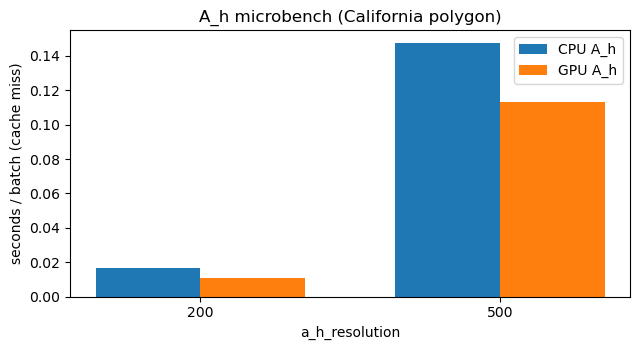

In [21]:
if RUN_AH_MICROBENCH and "ah_df" in globals() and not ah_df.empty:
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    x = np.arange(len(ah_df))
    w = 0.35
    ax.bar(x - w / 2, ah_df["cpu_seconds"], w, label="CPU A_h")
    if ah_df["gpu_seconds"].notna().any():
        ax.bar(x + w / 2, ah_df["gpu_seconds"], w, label="GPU A_h")
    ax.set_xticks(x, [str(v) for v in ah_df["resolution"]])
    ax.set_xlabel("a_h_resolution")
    ax.set_ylabel("seconds / batch (cache miss)")
    ax.set_title("A_h microbench (California polygon)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "ah_microbench_bars.png", dpi=140)
    plt.show()


## Continuation wall-clock (after terminal jobs)


In [22]:
def load_timing(run_root: Path | None) -> pd.DataFrame:
    if run_root is None:
        return pd.DataFrame()
    path = run_root / "timing_summary.jsonl"
    if not path.is_file():
        return pd.DataFrame()
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    return pd.DataFrame(rows)


timing = load_timing(RUN_ROOT)
if timing.empty:
    display(Markdown("No `timing_summary.jsonl` yet. Launch `run_fine_speed_benchmark.py` and re-run."))
else:
    timed = timing.loc[timing["timed"] == True].copy() if "timed" in timing.columns else timing.copy()
    display(Markdown("### All recorded rows (including prepare)"))
    display(timing)
    display(Markdown("### Timed forecast arms"))
    display(timed)


### All recorded rows (including prepare)

,run_id,arm,method,use_gpu,timed,force_rerun,seed,n_runs,max_forecast_events,output_root,config_path,log_path,command,ETAS_FINE_AH_GPU,started_at,finished_at,exit_code,wall_seconds,n_events,forecast_catalog
0,20260914_speed,prepare_inversion,thinning,False,False,False,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,0,2026-09-14T13:50:41Z,2026-09-14T13:50:55Z,0,14.013,52.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...
1,20260914_speed,thinning_cpu,thinning,False,True,True,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,0,2026-09-14T13:50:55Z,2026-09-14T13:51:06Z,0,10.869,52.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...
2,20260914_speed,thinning_gpu,thinning,True,True,True,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,1,2026-09-14T13:51:06Z,2026-09-14T13:51:14Z,0,8.672,52.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...
3,20260914_speed,prepare_inversion,thinning,False,False,False,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,0,2026-09-15T11:25:11Z,2026-09-15T11:25:13Z,0,1.939,52.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...
4,20260914_speed,prepare_FINE,FINE,False,False,False,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,0,2026-09-15T11:25:13Z,2026-09-15T11:25:15Z,1,1.900,NaN,NaN
5,20260914_speed,prepare_inversion,thinning,False,False,False,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,0,2026-09-15T11:26:07Z,2026-09-15T11:26:09Z,0,1.820,52.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...
6,20260914_speed,prepare_FINE,FINE,False,False,False,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,0,2026-09-15T11:26:09Z,2026-09-15T11:27:30Z,0,81.104,496.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...
7,20260914_speed,FINE_cpu,FINE,False,True,True,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,0,2026-09-15T11:27:30Z,2026-09-15T11:28:12Z,0,42.106,496.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...
8,20260914_speed,FINE_gpu,FINE,True,True,True,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,1,2026-09-15T11:28:12Z,2026-09-15T11:28:48Z,0,36.063,496.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...


### Timed forecast arms

,run_id,arm,method,use_gpu,timed,force_rerun,seed,n_runs,max_forecast_events,output_root,config_path,log_path,command,ETAS_FINE_AH_GPU,started_at,finished_at,exit_code,wall_seconds,n_events,forecast_catalog
1,20260914_speed,thinning_cpu,thinning,False,True,True,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,0,2026-09-14T13:50:55Z,2026-09-14T13:51:06Z,0,10.869,52.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...
2,20260914_speed,thinning_gpu,thinning,True,True,True,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,1,2026-09-14T13:51:06Z,2026-09-14T13:51:14Z,0,8.672,52.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...
7,20260914_speed,FINE_cpu,FINE,False,True,True,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,0,2026-09-15T11:27:30Z,2026-09-15T11:28:12Z,0,42.106,496.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...
8,20260914_speed,FINE_gpu,FINE,True,True,True,0,1,500,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/home/neriberman/Repos/etas-fine-speed-gpu/out...,/a/home/cc/students/csguests/neriberman/anacon...,1,2026-09-15T11:28:12Z,2026-09-15T11:28:48Z,0,36.063,496.0,/home/neriberman/Repos/etas-fine-speed-gpu/out...


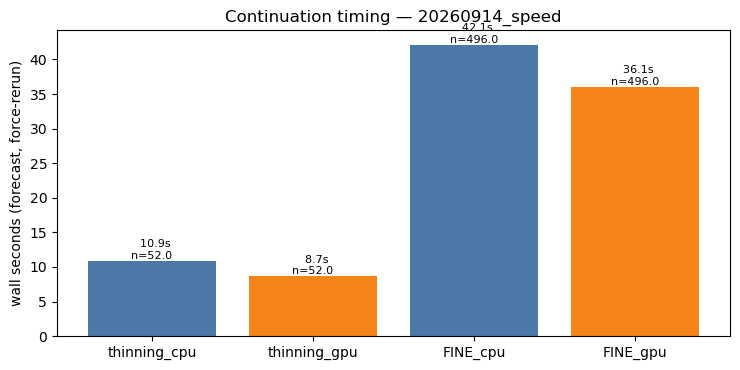

GPU helps **once per new parent**. After `A_h` cache is warm, do not expect Ogata proposals themselves to speed up.

,method,cpu_seconds,gpu_seconds,speedup_cpu_over_gpu,cpu_n_events,gpu_n_events,cpu_exit,gpu_exit
0,FINE,42.106,36.063,1.167568,496.0,496.0,0,0
1,thinning,10.869,8.672,1.253344,52.0,52.0,0,0


In [23]:
if "timed" in globals() and not timed.empty:
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    labels = timed["arm"].astype(str).tolist()
    values = timed["wall_seconds"].astype(float).tolist()
    colors = ["#4c78a8" if not gpu else "#f58518" for gpu in timed["use_gpu"].tolist()]
    ax.bar(labels, values, color=colors)
    ax.set_ylabel("wall seconds (forecast, force-rerun)")
    ax.set_title(f"Continuation timing — {resolved_run_id}")
    for i, (sec, n_ev) in enumerate(zip(values, timed.get("n_events", [None] * len(values)))):
        ax.text(i, sec, f"  {sec:.1f}s\nn={n_ev}", ha="center", va="bottom", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"continuation_wall_{resolved_run_id}.png", dpi=140)
    plt.show()

    speedup_rows = []
    for method, group in timed.groupby("method"):
        cpu = group.loc[group["use_gpu"] == False]
        gpu = group.loc[group["use_gpu"] == True]
        if cpu.empty or gpu.empty:
            continue
        cpu_s = float(cpu["wall_seconds"].iloc[0])
        gpu_s = float(gpu["wall_seconds"].iloc[0])
        speedup_rows.append(
            {
                "method": method,
                "cpu_seconds": cpu_s,
                "gpu_seconds": gpu_s,
                "speedup_cpu_over_gpu": cpu_s / gpu_s if gpu_s else np.nan,
                "cpu_n_events": cpu["n_events"].iloc[0],
                "gpu_n_events": gpu["n_events"].iloc[0],
                "cpu_exit": cpu["exit_code"].iloc[0],
                "gpu_exit": gpu["exit_code"].iloc[0],
            }
        )
    if speedup_rows:
        speedup_df = pd.DataFrame(speedup_rows)
        display(Markdown("GPU helps **once per new parent**. After `A_h` cache is warm, do not expect Ogata proposals themselves to speed up."))
        display(speedup_df)
else:
    display(Markdown("Waiting for timed continuation rows."))


## Catalog sanity (CPU vs GPU, same seed)

GPU `A_h` is `allclose`, not bit-identical. Event counts should be close; GR thinning with the same seed should match if `A_h` values stay within the thinning accept/reject path. Large count diffs are a red flag, not a speedup.


### `thinning`

CPU events=52, GPU events=52

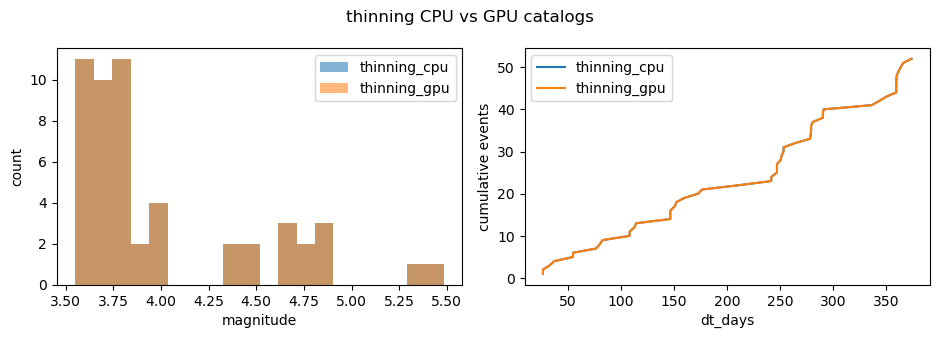

### `FINE`

CPU events=496, GPU events=496

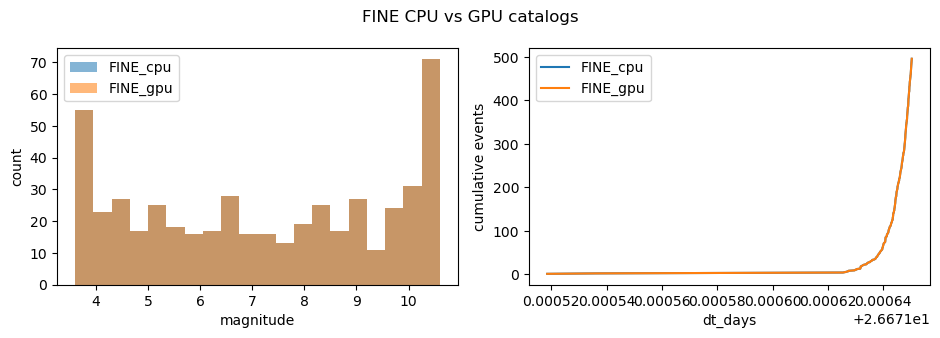

In [24]:
def load_arm_catalog(run_root: Path, arm: str, method: str) -> pd.DataFrame | None:
    path = speed_bench.find_forecast_catalog(run_root / "arms" / arm, method)
    if path is None or not path.is_file():
        return None
    return pd.read_csv(path)


if RUN_ROOT is None:
    display(Markdown("No run root — skip catalog compare."))
else:
    pairs = [("thinning_cpu", "thinning_gpu", "thinning"), ("FINE_cpu", "FINE_gpu", "FINE")]
    for cpu_arm, gpu_arm, method in pairs:
        cpu_cat = load_arm_catalog(RUN_ROOT, cpu_arm, method)
        gpu_cat = load_arm_catalog(RUN_ROOT, gpu_arm, method)
        if cpu_cat is None and gpu_cat is None:
            continue
        display(Markdown(f"### `{method}`"))
        n_cpu = 0 if cpu_cat is None else len(cpu_cat)
        n_gpu = 0 if gpu_cat is None else len(gpu_cat)
        display(Markdown(f"CPU events={n_cpu}, GPU events={n_gpu}"))
        if cpu_cat is None or gpu_cat is None or cpu_cat.empty or gpu_cat.empty:
            continue
        mag_col = "magnitude" if "magnitude" in cpu_cat.columns else "m"
        fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
        axes[0].hist(cpu_cat[mag_col], bins=20, alpha=0.55, label=cpu_arm)
        axes[0].hist(gpu_cat[mag_col], bins=20, alpha=0.55, label=gpu_arm)
        axes[0].set_xlabel("magnitude")
        axes[0].set_ylabel("count")
        axes[0].legend()
        t_col = "dt_days" if "dt_days" in cpu_cat.columns else None
        if t_col:
            axes[1].plot(np.sort(cpu_cat[t_col]), np.arange(1, n_cpu + 1), label=cpu_arm)
            axes[1].plot(np.sort(gpu_cat[t_col]), np.arange(1, n_gpu + 1), label=gpu_arm)
            axes[1].set_xlabel("dt_days")
            axes[1].set_ylabel("cumulative events")
            axes[1].legend()
        else:
            axes[1].axis("off")
        fig.suptitle(f"{method} CPU vs GPU catalogs")
        fig.tight_layout()
        fig.savefig(FIGURE_DIR / f"catalog_{method}_{resolved_run_id}.png", dpi=140)
        plt.show()


## Logs

If an arm failed, open `logs/<arm>.log` under the run root. Prepare rows (`timed=false`) include inversion and MAGNET train and should **not** be used as speedup denominators.

The 4-bucket in-loop timer (`A_h` miss / `lambda_s_total` / MAGNET / other) is not implemented yet; this notebook is wall-clock + kernel microbench only.
